# INVERTER CIRCUIT 32nm bulk CMOS

> Dataset source repository: https://github.com/GabriellJacinto/Electrical-Behaviour-Prediction
> Dataset Path: Electrical-Behaviour-Prediction/CMOS/32nm/NOT/Models/simu0/Advanced_Algorithms.ipynb

<small>

I'm using simu_0/treated_data dataset in this analysis

**Joined_data.csv:** contém os resultados brutos das simulações elétricas feitas no hspice (Monte Carlo).

**Treated_data.csv:** contém widths, tensões e temperaturas mapeadas.

O notebook advanced_algorithms usa o joined_data e depois gera o treated_data.

*No entanto, ainda não descobri a diferença entre simulação0 e simulação1. Estou usando a simul0.*

</small>

# Data Splitting

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset_path = "/home/eduarda/Repos/jupyter_ic/data/processed/CMOS/32nm/NOT/02_data_exploration/cmos_df.csv"
plots_dir = "/home/eduarda/Repos/jupyter_ic/figures/CMOS/32nm/NOT/03_train_val_test_splitting_plots"
df = pd.read_csv(dataset_path, index_col=0)

In [3]:
## Train, Validation, Test Sets & Scaling (StandardScaler)

First split: 75% training, 25% test
Secound split (train, validation):
33% of 75% ~ 25% of the original data becomes the validation set

Result:
- Train ~50%
- Validation ~25%
- Test 25%

In [4]:
X = df.drop(columns=['tphl', 'tplh', 'energy'])
y = df[['tphl', 'tplh', 'energy']]
print(X.shape)
print(y.shape)

(127771, 7)
(127771, 3)


In [5]:
from sklearn import set_config
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

set_config(transform_output="pandas")

seed = 23

# Train/Tesy set - train total 75% and test 25%
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=seed, test_size=0.25)


print("Train set X", X_train.shape)
print("Train set y", y_train.shape)
print("Test set X", X_test.shape)
print("Test set y", y_test.shape)

Train set X (95828, 7)
Train set y (95828, 3)
Test set X (31943, 7)
Test set y (31943, 3)


In [6]:
X_train.head()

,PV_nmos,PV_pmos,temperature,voltage,W NMOS,W PMOS,L
45470,0.5238,-0.4381,100.0,0.7,7.000000e-08,7.000000e-08,3.200000e-08
14820,0.5334,-0.4417,50.0,0.6,7.000000e-08,3.500000e-07,3.200000e-08
74778,0.5213,-0.4715,25.0,0.7,7.000000e-08,1.400000e-07,4.000000e-08
32927,0.5411,-0.4487,25.0,0.6,7.000000e-08,1.400000e-07,4.000000e-08
35007,0.5116,-0.4523,75.0,0.6,7.000000e-08,1.400000e-07,4.000000e-08


### Sets Visualization


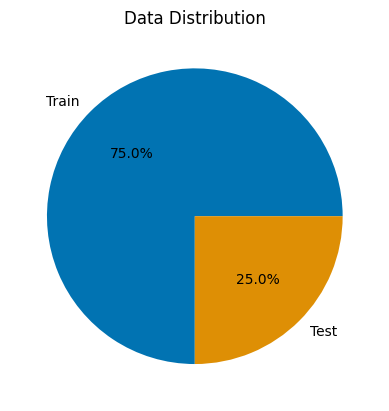

In [7]:
sizes = [len(X_train), len(X_test)]
labels = ['Train', 'Test']

colors = sns.color_palette('colorblind')[0:3]

plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%')
plt.title('Data Distribution')
plt.savefig(f"{plots_dir}/cmos_split_data_distribution.png")
plt.show()
plt.close()

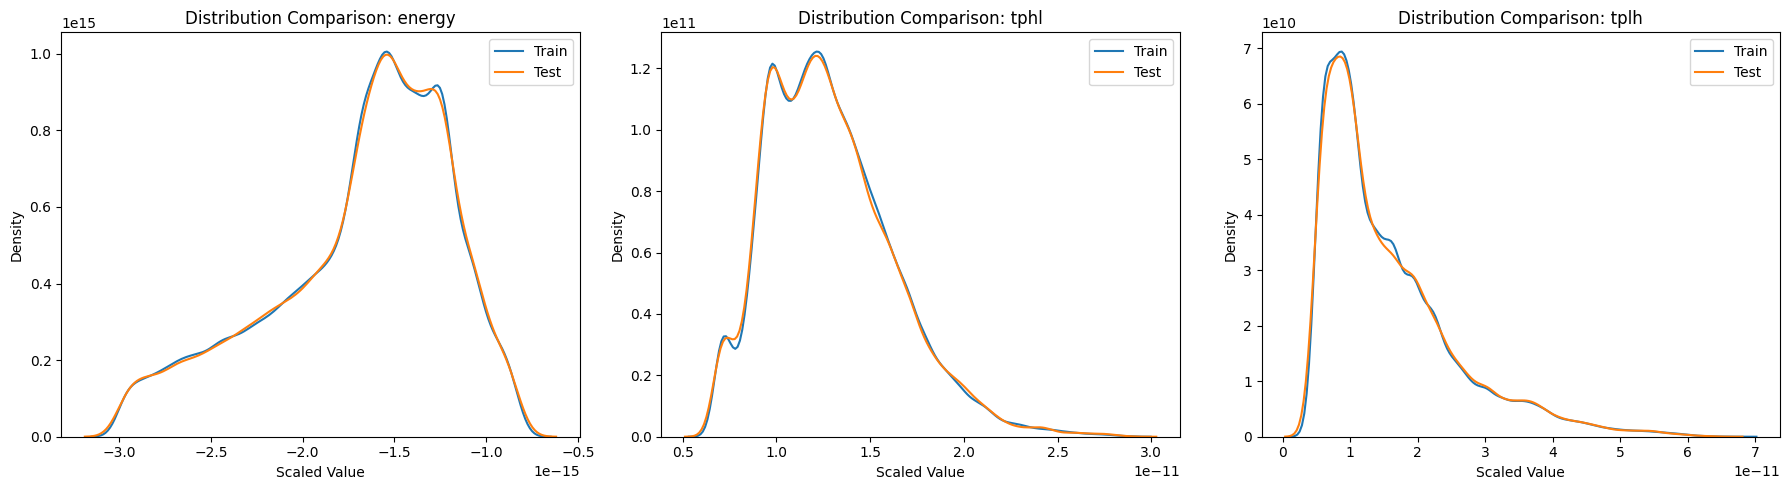

In [8]:
targets = ['energy', 'tphl', 'tplh']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(targets):
    sns.kdeplot(y_train[col], label='Train', ax=axes[i])
    sns.kdeplot(y_test[col], label='Test', ax=axes[i])
    
    axes[i].set_title(f'Distribution Comparison: {col}')
    axes[i].set_xlabel('Scaled Value')
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.tight_layout()
plt.savefig(f"{plots_dir}/cmos_dataset_distribution_comparison.png")
plt.show()
plt.close()

In [9]:
X_train.to_csv('/home/eduarda/Repos/jupyter_ic/data/processed/CMOS/32nm/NOT/03_train_val_test_splitting/X_train.csv', index=False)
X_test.to_csv('/home/eduarda/Repos/jupyter_ic/data/processed/CMOS/32nm/NOT/03_train_val_test_splitting/X_test.csv', index=False)

y_train.to_csv('/home/eduarda/Repos/jupyter_ic/data/processed/CMOS/32nm/NOT/03_train_val_test_splitting/y_train.csv', index=False)
y_test.to_csv('/home/eduarda/Repos/jupyter_ic/data/processed/CMOS/32nm/NOT/03_train_val_test_splitting/y_test.csv', index=False)